# Fusion Forge Training Series
# Transfer Learning & Fine-Tuning with Keras 3

A hands-on lesson using the **latest Keras 3 API** (multi-backend `keras`).

## What is Transfer Learning?

Training a large image model *from scratch* needs millions of images and a lot of
compute. **Transfer learning** lets us reuse a model that was already trained on a
huge dataset (ImageNet, ~1.2M images) and adapt it to our own, much smaller dataset.

The intuition: the early layers of a vision model learn *generic* features (edges,
colours, textures, shapes). Those features are useful for almost any image task, so
we keep them and only re-train the final decision layer(s) for our classes.

## The two-phase workflow you will build

```
        ┌──────────────────────────┐
Phase 1 │ Freeze the pre-trained    │  Only the new classifier head learns.
(fast)  │ base, train a new head    │  Fast, low risk of wrecking good features.
        └──────────────────────────┘
                    │
                    ▼
        ┌──────────────────────────┐
Phase 2 │ Unfreeze the base and     │  Gently adapt the pre-trained features
(fine)  │ train end-to-end, tiny LR │  to our dataset. Use a VERY small LR.
        └──────────────────────────┘
```

## Learning objectives

By the end of this notebook you will be able to:
1. Load an image dataset from disk and build an efficient `tf.data` pipeline.
2. Attach a new classification head to a frozen pre-trained model (**Xception**).
3. Train in two phases (feature extraction → fine-tuning) and explain *why*.
4. Read learning curves and a confusion matrix to judge model quality.

## Steps in this notebook
1. Take a model pre-trained on ImageNet (**Xception**).
2. Freeze it and add a new classification head.
3. Train the head on the *flowers* dataset (5 classes).
4. Fine-tune the whole network with a very low learning rate.
5. Evaluate, plot the learning curves, and test on real images.

In [16]:
import os

# Let TensorFlow grow GPU memory on demand instead of grabbing a fixed slice up
# front. Important on unified-memory devices (e.g. GB10) to avoid early OOM.
os.environ.setdefault("TF_FORCE_GPU_ALLOW_GROWTH", "true")
# Fall back to a working conv algorithm instead of erroring if autotuning OOMs.
os.environ.setdefault("XLA_FLAGS", "--xla_gpu_strict_conv_algorithm_picker=false")

import keras
from keras import layers
import tensorflow as tf  # used only for the tf.data input pipeline

# Enable memory growth explicitly as well (must run before any GPU op).
for gpu in tf.config.list_physical_devices("GPU"):
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print("Could not set memory growth:", e)

print("Keras version:", keras.__version__)
print("Backend:", keras.backend.backend())
print("GPUs:", tf.config.list_physical_devices("GPU"))

Keras version: 3.15.0
Backend: tensorflow
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Load the dataset

We reuse the TensorFlow *flower_photos* dataset (5 classes). Images are loaded at their
raw `[0, 255]` range — scaling happens later inside the model.

In [ ]:
import os

IMG_SIZE = 224

dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
dataset_dir = keras.utils.get_file("flower_photos", origin=dataset_url, untar=True)

# The archive extracts with a nested `flower_photos/flower_photos/<class>/` layout,
# so descend into the folder that actually contains the class sub-directories.
nested_dir = os.path.join(dataset_dir, "flower_photos")
if os.path.isdir(nested_dir):
    dataset_dir = nested_dir

full_dataset = keras.utils.image_dataset_from_directory(
    dataset_dir,
    labels="inferred",
    label_mode="int",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=None,
    shuffle=True,
    seed=42,
)

class_names = full_dataset.class_names
n_classes = len(class_names)
print("Classes:", class_names)

Found 3670 files belonging to 5 classes.


I0000 00:00:1783561298.889864   70644 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1783561298.892991   70644 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1783561298.896047   70644 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1783561299.081374   70644 cuda_executor.cc:1015] successful NUMA node read from SysFS ha

Classes: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


### Peek at the data

**Always look at your data before training.** It helps you catch label mistakes,
weird images, or class imbalance early. Below we show one example image per class.

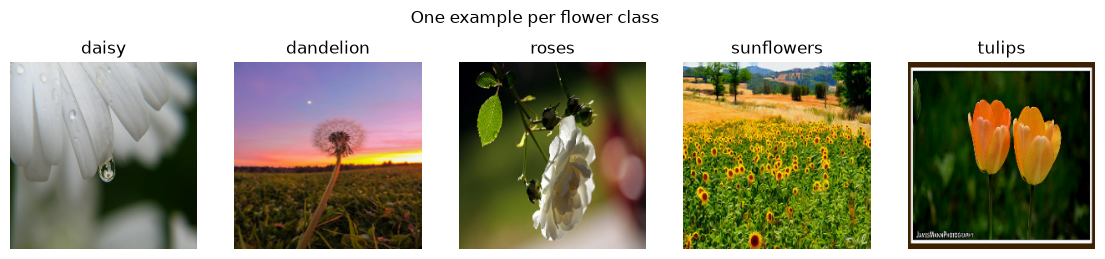

In [17]:
import matplotlib.pyplot as plt

# Grab one image for each class so students can see what the model must learn.
seen = {}
for image, label in full_dataset:
    idx = int(label.numpy())
    if idx not in seen:
        seen[idx] = image.numpy().astype("uint8")
    if len(seen) == n_classes:
        break

plt.figure(figsize=(14, 3))
for idx in range(n_classes):
    plt.subplot(1, n_classes, idx + 1)
    plt.imshow(seen[idx])
    plt.title(class_names[idx])
    plt.axis("off")
plt.suptitle("One example per flower class")
plt.show()

## 2. Train / validation / test split

We split the data into three disjoint parts, each with a different job:

- **Train (75%)** — the model learns from these images.
- **Validation (15%)** — checked after every epoch to tune choices and spot overfitting. The model never learns from it.
- **Test (10%)** — touched **once** at the very end to get an honest score on unseen data.

In [ ]:
dataset_size = tf.data.experimental.cardinality(full_dataset).numpy()

test_size = int(dataset_size * 0.10)
valid_size = int(dataset_size * 0.15)
train_size = dataset_size - test_size - valid_size

test_set_raw = full_dataset.take(test_size)
valid_set_raw = full_dataset.skip(test_size).take(valid_size)
train_set_raw = full_dataset.skip(test_size + valid_size).take(train_size)

print(f"train={train_size}, valid={valid_size}, test={test_size}")

train=2753, valid=550, test=367


## 3. Data augmentation + input pipeline

Augmentation is applied only to the training set. Notice there is **no** manual
`preprocess_input` step here anymore — pixel scaling is now a layer inside the model.

In [ ]:
batch_size = 16  # small batch keeps GPU memory usage modest

data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
    ],
    name="data_augmentation",
)

AUTOTUNE = tf.data.AUTOTUNE

train_set = (
    train_set_raw.shuffle(1000)
    .batch(batch_size)
    .map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)
valid_set = valid_set_raw.batch(batch_size).prefetch(AUTOTUNE)
test_set = test_set_raw.batch(batch_size).prefetch(AUTOTUNE)

## 4. Build the transfer-learning model

- `Rescaling` maps `[0, 255]` pixels to `[-1, 1]` (what Xception expects).
- The frozen `base_model` is called with `training=False` so its BatchNorm layers stay
  in inference mode (critical for correct fine-tuning later).
- A `Dropout` layer is added for regularization.

In [ ]:
base_model = keras.applications.Xception(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
)
base_model.trainable = False

inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = layers.Rescaling(scale=1 / 127.5, offset=-1)(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(n_classes, activation="softmax")(x)

model = keras.Model(inputs, outputs)
model.summary(show_trainable=True)

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_2 (InputLayer)  │ (None, 224, 224, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ rescaling (Rescaling)       │ (None, 224, 224, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ xception (Functional)       │ (None, 7, 7, 2048)    │ 20,861,480 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ global_average_pooling2d    │ (None, 2048)          │          0 │   -   │
│ (GlobalAveragePooling2D)    │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout (Dropout)           │ (None, 2048)          │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense (Dense)               │ (None, 5)             │     10,245 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 20,871,725 (79.62 MB)

 Trainable params: 10,245 (40.02 KB)

 Non-trainable params: 20,861,480 (79.58 MB)

## 5. Train the new classification head

Only the top `Dense` layer is trainable at this stage.

In [ ]:
model.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.2, momentum=0.9),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

history = model.fit(train_set, epochs=5, validation_data=valid_set)

Epoch 1/5


/home/nizare/GitHub/dl-ai570/.venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1783561327.718169   70748 service.cc:146] XLA service 0xf26e880024e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1783561327.718209   70748 service.cc:154]   StreamExecutor device (0): NVIDIA GB10, Compute Capability 12.1
2026-07-08 18:42:07.772615: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-07-08 18:42:08.050865: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 92400
'+ptx85' is not a recognized feature for this target (ign

  5/173 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.4500 - loss: 1.9224 

I0000 00:00:1783561338.037084   70748 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


172/173 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7489 - loss: 4.2815

E0000 00:00:1783561342.933001   70748 gpu_timer.cc:183] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1783561343.018533   70748 gpu_timer.cc:183] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-08 18:42:23.045738: W external/local_tsl/tsl/framework/bfc_allocator.cc:291] Allocator (GPU_0_bfc) ran out of memory trying to allocate 4.32GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
E0000 00:00:1783561343.139918   70748 gpu_timer.cc:183] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1783561343.224805   70748 gpu_timer.cc:183] Delay kernel timed out: measured tim

173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.7490 - loss: 4.2800

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

173/173 ━━━━━━━━━━━━━━━━━━━━ 25s 72ms/step - accuracy: 0.7490 - loss: 4.2800 - val_accuracy: 0.8345 - val_loss: 2.5415
Epoch 2/5
Epoch 2/5
173/173 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.8325 - loss: 3.0349 - val_accuracy: 0.8691 - val_loss: 2.4643
Epoch 3/5
173/173 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.8304 - loss: 4.0025 - val_accuracy: 0.7927 - val_loss: 4.9994
Epoch 4/5
173/173 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.8460 - loss: 3.9404 - val_accuracy: 0.8982 - val_loss: 2.2848
Epoch 5/5
173/173 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.8710 - loss: 2.5577 - val_accuracy: 0.9091 - val_loss: 1.5230


## 6. Fine-tune the entire model

Unfreeze the base model and retrain end-to-end with a **very low** learning rate.
We must recompile after changing `trainable`. The base model still runs in inference
mode (we passed `training=False` when building), so BatchNorm statistics stay frozen.

In [ ]:
base_model.trainable = True

model.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

history_fine = model.fit(train_set, epochs=10, validation_data=valid_set)

Epoch 1/10


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

172/173 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.5799 - loss: 1.2528

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.5797 - loss: 1.2528

2026-07-08 18:43:40.936234: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'input_reduce_fusion', 16 bytes spill stores, 16 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'input_add_reduce_fusion', 16 bytes spill stores, 16 bytes spill loads

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


173/173 ━━━━━━━━━━━━━━━━━━━━ 42s 155ms/step - accuracy: 0.5797 - loss: 1.2528 - val_accuracy: 0.7509 - val_loss: 1.0205
Epoch 2/10


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


173/173 ━━━━━━━━━━━━━━━━━━━━ 19s 109ms/step - accuracy: 0.7984 - loss: 0.5908 - val_accuracy: 0.8582 - val_loss: 0.3847
Epoch 3/10
173/173 ━━━━━━━━━━━━━━━━━━━━ 19s 110ms/step - accuracy: 0.8511 - loss: 0.4059 - val_accuracy: 0.9218 - val_loss: 0.2136
Epoch 4/10
173/173 ━━━━━━━━━━━━━━━━━━━━ 18s 102ms/step - accuracy: 0.8772 - loss: 0.3255 - val_accuracy: 0.8836 - val_loss: 0.2670
Epoch 5/10
173/173 ━━━━━━━━━━━━━━━━━━━━ 18s 102ms/step - accuracy: 0.9139 - loss: 0.2545 - val_accuracy: 0.9000 - val_loss: 0.2852
Epoch 6/10
173/173 ━━━━━━━━━━━━━━━━━━━━ 18s 103ms/step - accuracy: 0.9303 - loss: 0.2176 - val_accuracy: 0.9564 - val_loss: 0.1303
Epoch 7/10
173/173 ━━━━━━━━━━━━━━━━━━━━ 18s 103ms/step - accuracy: 0.9332 - loss: 0.2088 - val_accuracy: 0.9345 - val_loss: 0.1709
Epoch 8/10
173/173 ━━━━━━━━━━━━━━━━━━━━ 18s 103ms/step - accuracy: 0.9430 - loss: 0.1690 - val_accuracy: 0.9564 - val_loss: 0.1459
Epoch 9/10
173/173 ━━━━━━━━━━━━━━━━━━━━ 19s 110ms/step - accuracy: 0.9466 - loss: 0.1668 - val

## 7. Evaluate on the test set

In [ ]:
test_loss, test_acc = model.evaluate(test_set)
print(f"Test accuracy: {test_acc:.4f}")

22/23 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9545 - loss: 0.1110

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 277ms/step - accuracy: 0.9537 - loss: 0.1125
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 277ms/step - accuracy: 0.9537 - loss: 0.1125
Test accuracy: 0.9537


## 8. Track the learning (accuracy & loss curves)

Combine the history from the head-training phase and the fine-tuning phase into a
single plot so we can see how accuracy and loss evolved across all epochs. The
dashed vertical line marks where fine-tuning started.

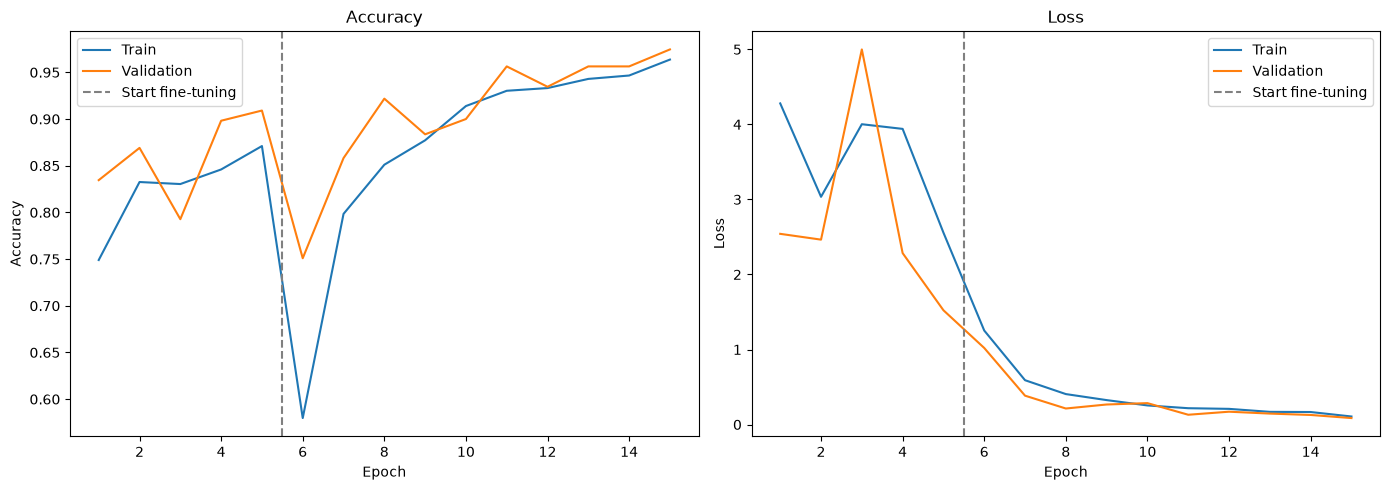

In [ ]:
import matplotlib.pyplot as plt

# Concatenate metrics from both training phases
acc = history.history["accuracy"] + history_fine.history["accuracy"]
val_acc = history.history["val_accuracy"] + history_fine.history["val_accuracy"]
loss = history.history["loss"] + history_fine.history["loss"]
val_loss = history.history["val_loss"] + history_fine.history["val_loss"]

fine_tune_start = len(history.history["accuracy"])  # epoch where fine-tuning began
epochs_range = range(1, len(acc) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_range, acc, label="Train")
ax1.plot(epochs_range, val_acc, label="Validation")
ax1.axvline(fine_tune_start + 0.5, color="gray", linestyle="--", label="Start fine-tuning")
ax1.set_title("Accuracy")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.legend()

ax2.plot(epochs_range, loss, label="Train")
ax2.plot(epochs_range, val_loss, label="Validation")
ax2.axvline(fine_tune_start + 0.5, color="gray", linestyle="--", label="Start fine-tuning")
ax2.set_title("Loss")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.legend()

plt.tight_layout()
plt.show()

## 9. Test the model on real images

Below we run a few sanity checks on the held-out **test set**:
1. A confusion matrix + per-class report over the whole test set.
2. A visual grid showing predictions on individual test images (green = correct, red = wrong).

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


              precision    recall  f1-score   support

       daisy       0.99      0.92      0.95        72
   dandelion       0.95      0.98      0.97        86
       roses       0.93      0.88      0.90        59
  sunflowers       0.97      0.98      0.98        66
      tulips       0.88      0.93      0.90        84

    accuracy                           0.94       367
   macro avg       0.94      0.94      0.94       367
weighted avg       0.94      0.94      0.94       367



2026-07-08 18:47:30.318270: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


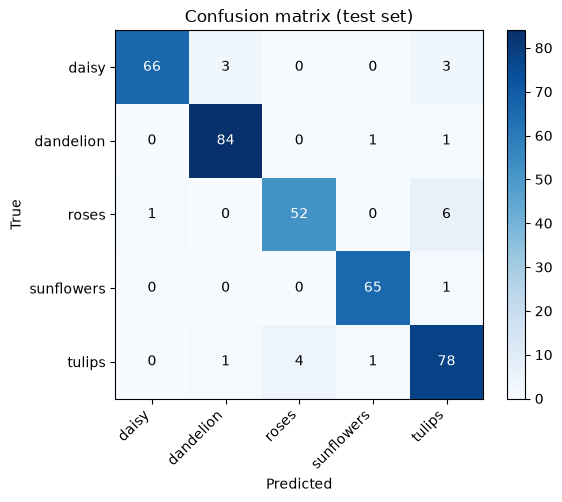

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# Collect true labels and predictions in a SINGLE pass over the test set.
# (The source dataset was built with shuffle=True, which reshuffles on every
# iteration — so predicting and reading labels in separate passes would
# misalign them. Predict batch-by-batch to keep them in sync.)
y_true, y_pred = [], []
for images, labels in test_set:
    probs = model.predict(images, verbose=0)
    y_true.append(labels.numpy())
    y_pred.append(np.argmax(probs, axis=1))

y_true = np.concatenate(y_true)
y_pred = np.concatenate(y_pred)

print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(n_classes))
ax.set_yticks(range(n_classes))
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion matrix (test set)")
for i in range(n_classes):
    for j in range(n_classes):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")
fig.colorbar(im)
plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


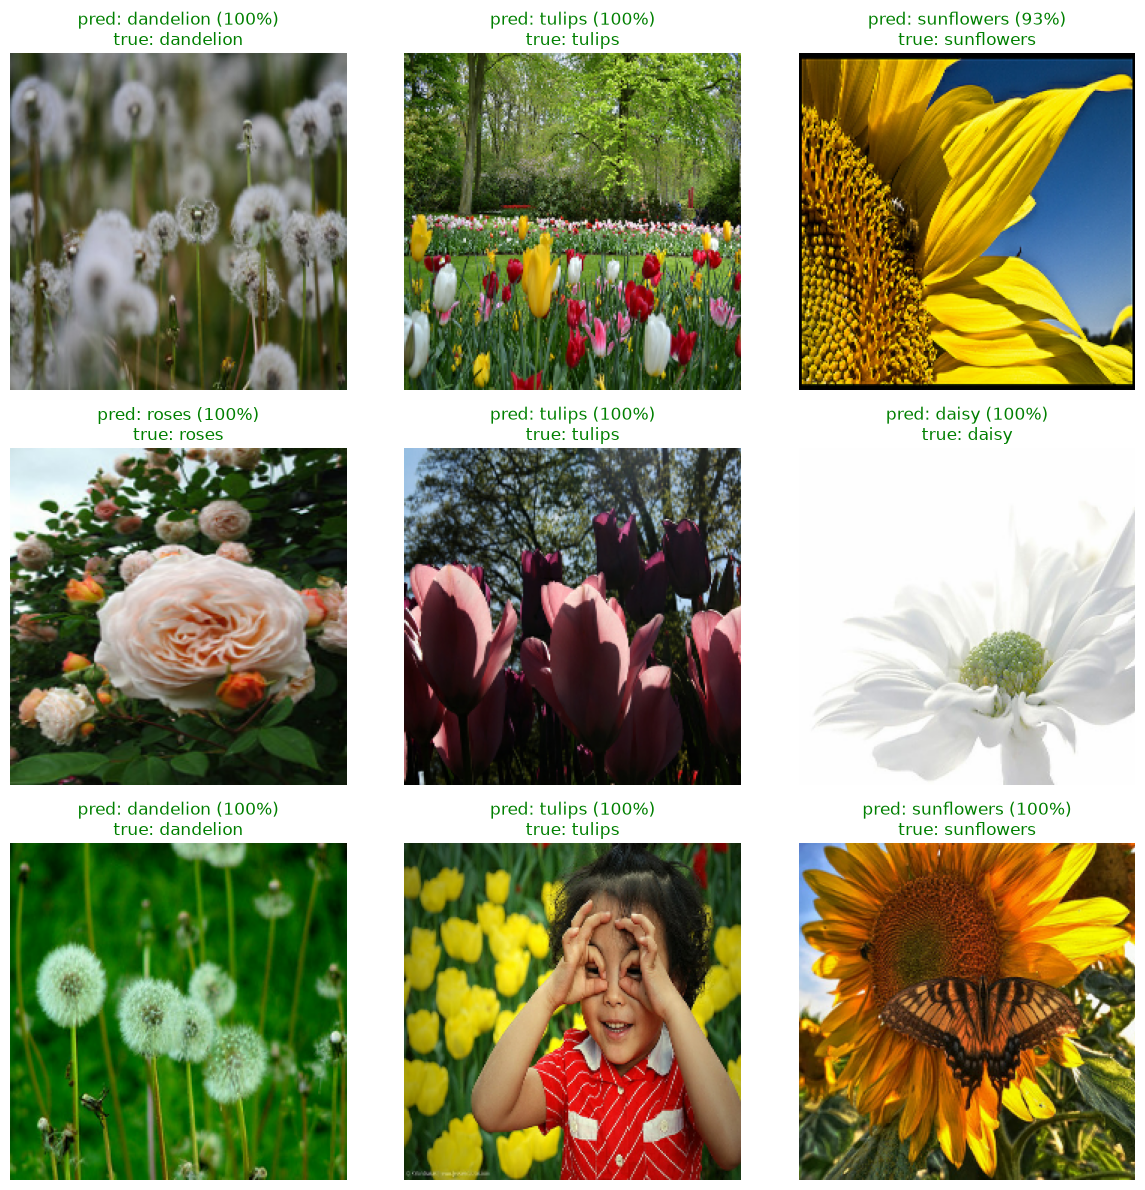

In [ ]:
# Visualize predictions on one batch of test images
images, labels = next(iter(test_set))
probs = model.predict(images)
preds = np.argmax(probs, axis=1)

n_show = min(9, images.shape[0])
plt.figure(figsize=(12, 12))
for i in range(n_show):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    true_name = class_names[labels[i].numpy()]
    pred_name = class_names[preds[i]]
    confidence = probs[i][preds[i]]
    correct = pred_name == true_name
    ax.set_title(
        f"pred: {pred_name} ({confidence:.0%})\ntrue: {true_name}",
        color="green" if correct else "red",
    )
    plt.axis("off")
plt.tight_layout()
plt.show()

## 10. Key takeaways & exercises

### Key takeaways
- **Transfer learning** reuses features learned on a huge dataset, so we get strong
  results from a small dataset and little training time.
- **Freeze first, fine-tune later.** Training the new head first prevents large,
  random gradients from destroying the pre-trained weights.
- **Fine-tune with a tiny learning rate** (here 20× smaller) so we only *nudge* the
  pre-trained features instead of overwriting them.
- Keep BatchNorm in inference mode during fine-tuning (`training=False`) so its
  running statistics don't get corrupted.
- Do preprocessing (`Rescaling`) **inside** the model — the model then accepts raw
  `[0, 255]` images and is easier to deploy.

### Try it yourself 🛠️
1. **Swap the backbone.** Replace `Xception` with `keras.applications.MobileNetV2`
   or `ResNet50`. How do accuracy and training speed change? (Remember each model
   expects a specific input size / rescaling.)
2. **Skip fine-tuning.** Comment out Phase 2 and compare the test accuracy. How much
   does fine-tuning actually help here?
3. **Add an EarlyStopping callback** (`keras.callbacks.EarlyStopping`) to stop
   training automatically when validation loss stops improving.
4. **Stronger augmentation.** Add `RandomZoom` / `RandomContrast` and see whether the
   gap between train and validation accuracy shrinks.
5. **Save & reload** the trained model with `model.save("flowers.keras")` and
   `keras.models.load_model(...)`, then predict on a single downloaded image.